# The experiments (H-04)

Each section loads saved runs from `metrics/` and makes a plot or a table. The notebook does not need the cluster. The tables of all runs are in `docs/results.md`, and the report is `DESIGN.md`.

In [1]:
import json
import sys
from pathlib import Path

from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))
from notebook import proof  # noqa: E402

# Run ids in metrics/ (sessions 1 and 2, 2026-09-29). 100% load = RATE100 = 0.9 scripts each second (the E2 knee).
RUNS = {
    "m4_150": "e3-c-150",        # M4 at 150%, layout C (P/D)
    "m1": "e11-pass",            # M1 traffic: M3 with the metrics proxy in pass mode (layout A, 100%)
    "m2": "e6-on",               # M2 shared prefix, prefix cache on (layout C, 100%)
    "m3": "e11-frozen",          # M3: pod B serves a frozen snapshot of an empty pod (layout A, 100%)
    "m4": "e3-c-100",            # M4 mixed interactive and batch (layout C, 100%)
    "m2_prefix_off": "e6-noprefix", "e1_8k": "e1-8k", "e1_24k": "e1-24k",
    "e12_abort": "e12-abort",    # M4 at 100%, 20% of the streams closed in the middle
    "e8_ramp": "e8-a-ramp",      # layout A: pod B restarts, then the warm controller ramps it
    "e8_jump": "e8-a-jump",      # layout A: the returned pod gets the full weight at once
    "e8_warmup": "e8-c-warmup", "e8_immediate": "e8-c-immediate",  # layout C: the one decode pod restarts
    "m2_fp8kv": "e6-fp8kv", "e2_soak": "e2-soak",
    "e14": ["e14-on-int", "e14-off-int", "e14-on-batch", "e14-off-batch"],  # split on/off, retrieve class
}


def show(path):
    if path is None:
        print("no data yet")
    else:
        display(Image(filename=str(path)))


## Four resources (H-23)

The four scarce resources, each with its measured peak. Decode slots and KV blocks set the limit of our traffic. The hop costs 0.5 to 0.8 s for each split request. A decode pod that restarts is out for about 5 minutes.

In [2]:
for row in proof.four_resources():
    print(row)

{'resource': 'decode slots', 'metric': 'vllm:num_requests_running (decode pod), --max-num-seqs=24', 'peak': 24.0, 'run': 'e3-c-150'}
{'resource': 'KV blocks', 'metric': 'vllm:kv_cache_usage_perc (decode pod)', 'peak': 0.944, 'run': 'e13-gate'}
{'resource': 'hop bandwidth', 'metric': 'LMCache tokens loaded each second; split TTFT median (unshared)', 'peak': 9938.489, 'run': 'e6-fp8kv; e4-hop 0.7775 s'}
{'resource': 'warmup time', 'metric': 'seconds with no decode pod: first 503 to the first call on the new pod', 'peak': 290, 'run': 'e8-c-warmup (no warmup: 275 s)'}


## E1: capacity at fixed prompt lengths

Prompts of 8,000 and 24,000 tokens, straight to the gateway. All calls were ok up to 32 and 24 concurrent requests, with no preemption. At 24K tokens, the TTFT grows with the prefill queue.

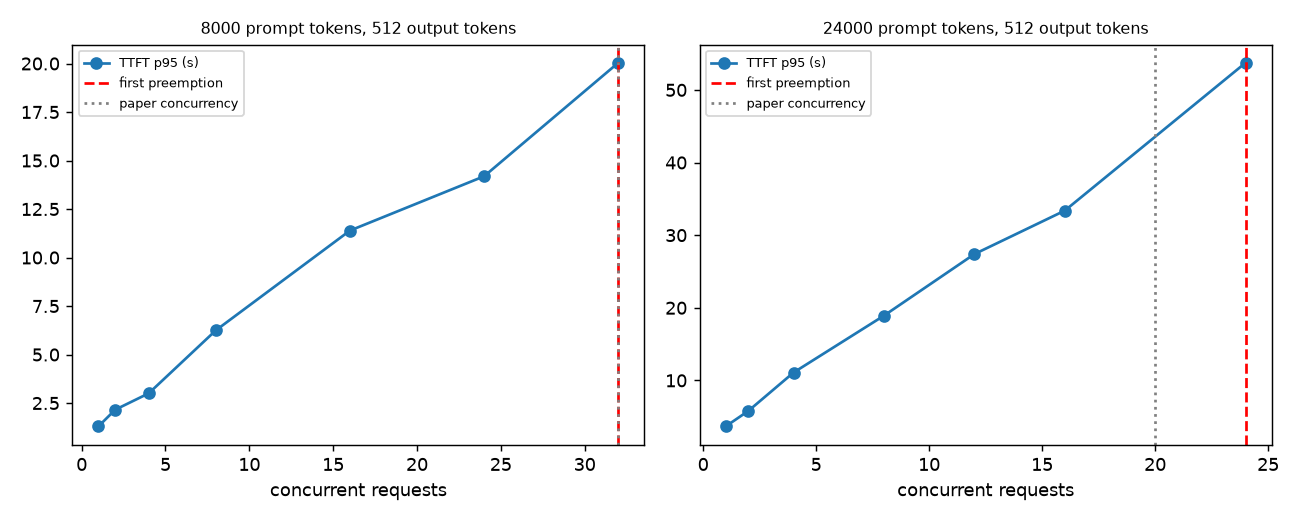

In [3]:
show(proof.capacity({8000: proof.load_run("e1-8k"), 24000: proof.load_run("e1-24k")}, {8000: 32, 24000: 20}))

## E2: the soak and the knee

The soak adds 0.05 scripts each second each minute. The first capacity shed sets RATE100.

{'rate100': 0.9, 'first_shed_s': 1082.6, 'shed_minute': 18, 'reason': '503 timeout_queue'}


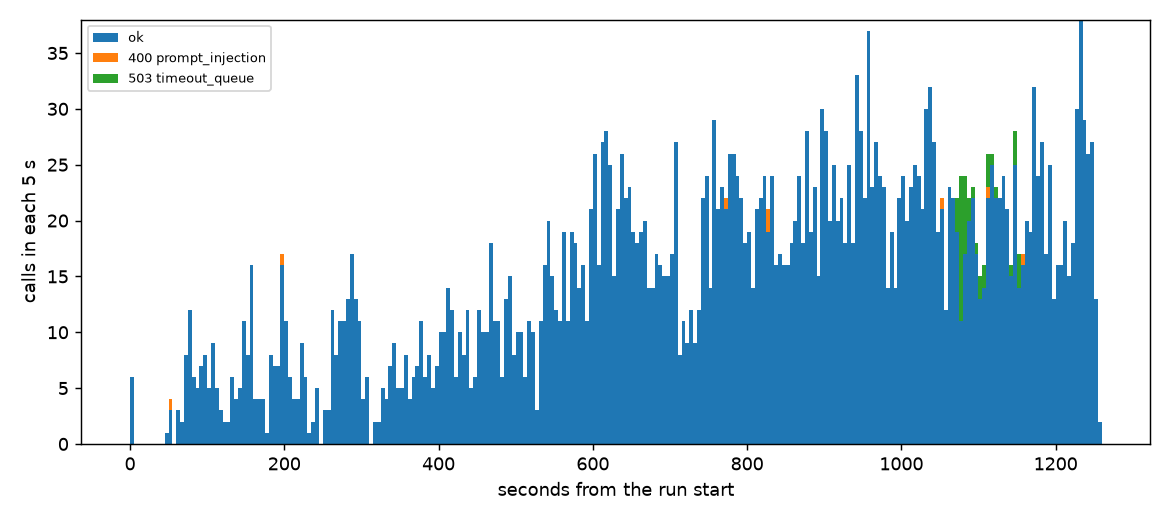

In [4]:
print(proof.knee_rate(proof.load_run("e2-soak")))
show(proof.soak(proof.load_run("e2-soak")))

## E3: layout C (P/D) against layout A (two whole pods)

Layout A was better at each load of the M4 replay. The decode pod of layout C was the bottleneck.

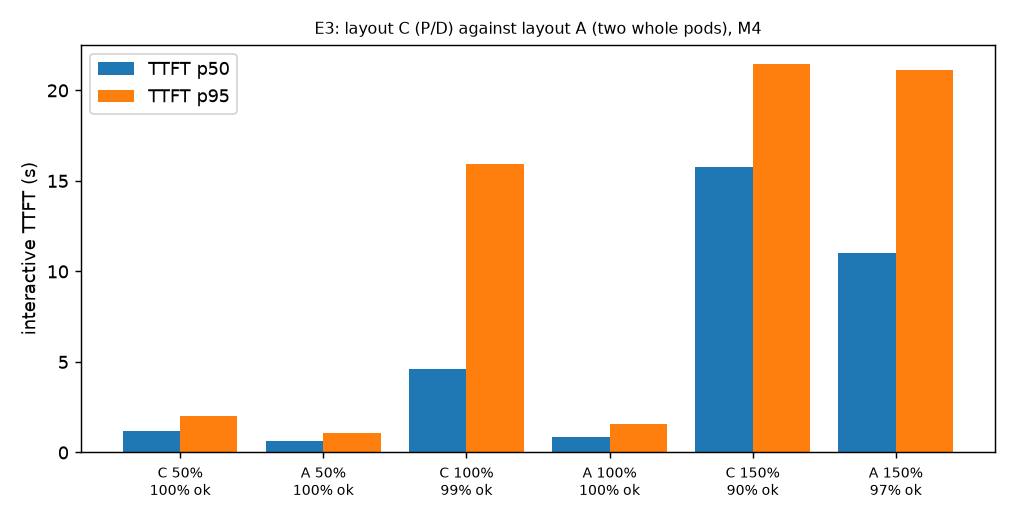

In [5]:
show(proof.ttft_bars([(f"{arm} {p}%", f"e3-{arm.lower()}-{p}") for p in (50, 100, 150) for arm in ("C", "A")],
                     "e3-topology.png", "E3: layout C (P/D) against layout A (two whole pods), M4"))

## E3 again on 8 x A100 80 GB (2026-10-01)

No H100 had stock, so E3 ran again on one node with 8 x A100 80 GB. Both layouts had 32 decode sequences. The levels are scripts each second, lower than on the H100. Layout A had about half of the TTFT p50 of layout C at each level. At 0.45, the router shed 117 interactive calls in layout C, and 2 in layout A.

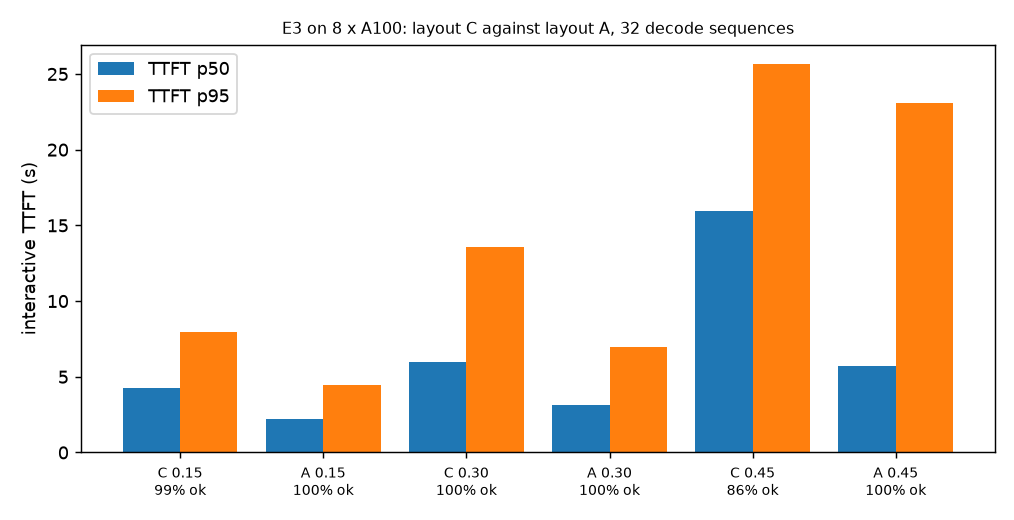

In [6]:
show(proof.ttft_bars([(f"{arm} {lvl}", rid) for lvl, c, a in (("0.15", "e3-c32-r015", "e3-a32-r015"),
                                                          ("0.30", "e3-c32-r030", "e3-a32-r030"),
                                                          ("0.45", "e3-c32-50", "e3-a32-r045"))
                      for arm, rid in (("C", c), ("A", a))],
                     "e3-a100.png", "E3 on 8 x A100: layout C against layout A, 32 decode sequences"))

## E4: the hop through the LMCache tier against NIXL

With the store barrier, the LMCache hop takes 0.5 to 0.8 s. NIXL between two pods used TCP and took about 4 s.

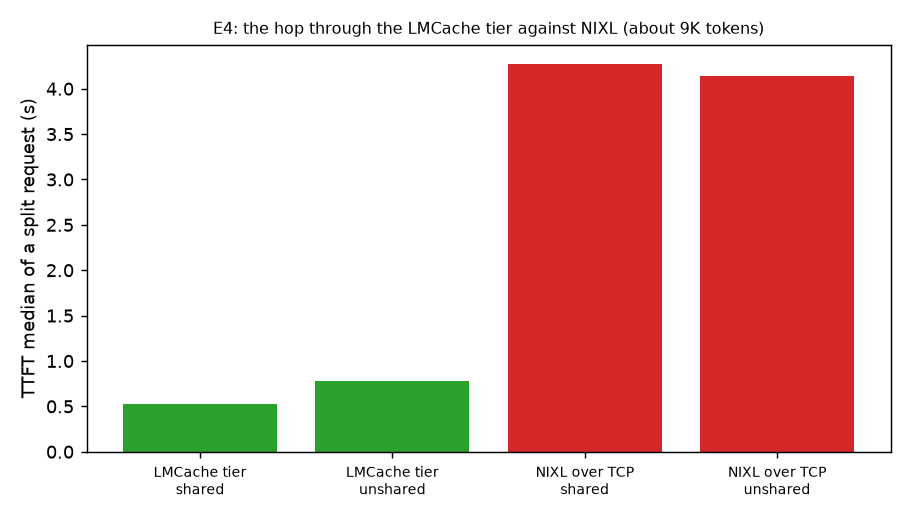

In [7]:
show(proof.hop_plot({"LMCache tier": "e4-hop", "NIXL over TCP": "e4-hop-nixl"}))

## E5: the split protects the other decode streams

One extra prompt either splits or stays on the decode pod, next to 16 decode streams. The split keeps the ITL of the other streams low. Even with the split, the ITL p95 of 16 streams stayed above SLO-2.

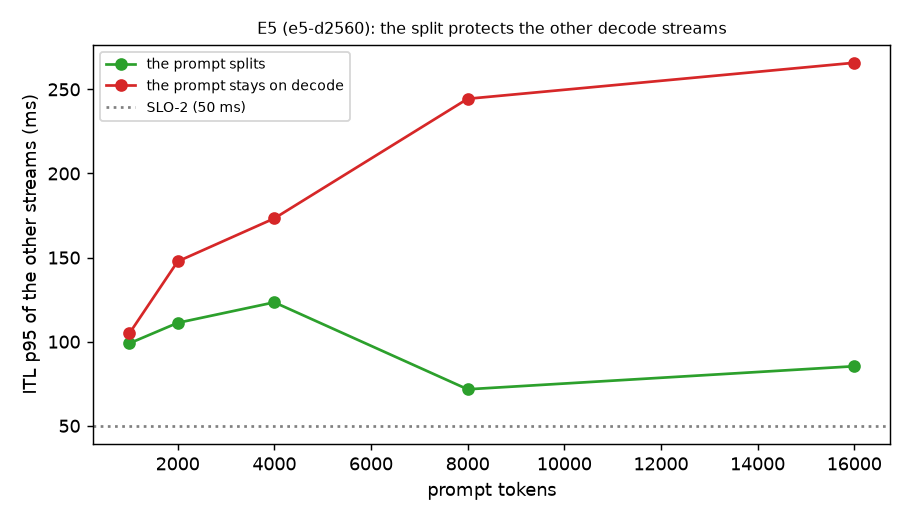

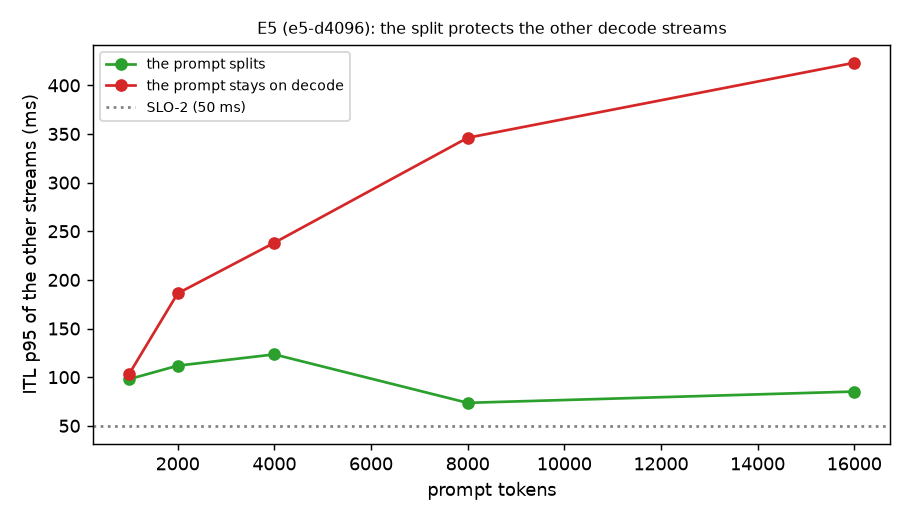

In [8]:
show(proof.split_itl_plot("e5-d2560"))
show(proof.split_itl_plot("e5-d4096"))

## E6: prefix cache and KV format

The prefix cache saved prefill work, and fp8 KV saved memory.

In [9]:
for row in proof.kv_table([proof.load_run(r) for r in ("e6-on", "e6-noprefix", "e6-fp8kv")]):
    print(row)

{'run': 'e6-on', 'decode_kv_use_mean': 0.135, 'decode_kv_use_max': 0.57, 'decode_prefix_hit_ratio_mean': 0.441, 'lmcache_hit_tokens_per_s_mean': 4374, 'interactive_ttft_p50_s': 0.4348, 'interactive_ttft_p95_s': 1.2806}
{'run': 'e6-noprefix', 'decode_kv_use_mean': 0.133, 'decode_kv_use_max': 0.452, 'decode_prefix_hit_ratio_mean': None, 'lmcache_hit_tokens_per_s_mean': 4471, 'interactive_ttft_p50_s': 0.599, 'interactive_ttft_p95_s': 1.2912}
{'run': 'e6-fp8kv', 'decode_kv_use_mean': 0.055, 'decode_kv_use_max': 0.26, 'decode_prefix_hit_ratio_mean': 0.677, 'lmcache_hit_tokens_per_s_mean': 5747, 'interactive_ttft_p50_s': 0.2299, 'interactive_ttft_p95_s': 1.7652}


## E7: ghost prefixes after a cache clear

The CPU tier gave the cleared prefixes back at once, so the token hit ratio did not fall. The next section has the run with no CPU tier.

In [10]:
for r in ("e7-precise", "e7-approx"):
    print(json.dumps(json.loads((ROOT / "metrics" / r / "ghosts-by-threshold.json").read_text()), indent=1))

{
 "run": "e7-precise",
 "clear": "2026-09-30T00:22:56+00:00",
 "threshold": 2048,
 "rule": "a ghost: not split, with 2,048 or more uncached tokens (the router expected cached tokens that were gone)",
 "before": {
  "requests": 180,
  "split": 13,
  "uncached_ge_2048": 20,
  "not_split_ghosts": 20,
  "token_hit_ratio": 0.762
 },
 "after_60s": {
  "requests": 87,
  "split": 3,
  "uncached_ge_2048": 7,
  "not_split_ghosts": 7,
  "token_hit_ratio": 0.789
 },
 "after": {
  "requests": 179,
  "split": 4,
  "uncached_ge_2048": 12,
  "not_split_ghosts": 12,
  "token_hit_ratio": 0.813
 }
}
{
 "run": "e7-approx",
 "clear": "2026-09-30T00:29:24+00:00",
 "threshold": 2048,
 "rule": "a ghost: not split, with 2,048 or more uncached tokens (the router expected cached tokens that were gone)",
 "before": {
  "requests": 167,
  "split": 30,
  "uncached_ge_2048": 6,
  "not_split_ghosts": 6,
  "token_hit_ratio": 0.884
 },
 "after_60s": {
  "requests": 85,
  "split": 7,
  "uncached_ge_2048": 3,
  "not_spl

## E7 again: no CPU tier (2026-10-01)

In layout A with no KV connector, the run clears the prefix cache of pod B at 150 s. Pod B sent one `AllBlocksCleared` event and no `BlockRemoved` event. The router still sent the next call of each warm session to pod B. The precise index did this for 15 of 15 sessions, and the approximate index for 10 of 10. Each of these calls missed the cache once. Thus the precise index did not act on the clear.

In [11]:
for r in ("e7b-precise", "e7b-approx2"):
    g = json.loads((ROOT / "metrics" / r / "ghosts.json").read_text())
    print(r, {k: g[k] for k in ("warm_sessions", "eligible", "ghosts", "ghost_ratio")})
    for ep, v in json.loads((ROOT / "metrics" / r / "kv-events.json").read_text())["by_endpoint"].items():
        print("   ", ep, "stored", v["stored"], "removed", v["removed"], "cleared", v["cleared"])

e7b-precise {'warm_sessions': 15, 'eligible': 151, 'ghosts': 15, 'ghost_ratio': 0.0993}
    tcp://10.42.0.78:5556 stored {'GPU': 4343} removed {} cleared 1
    tcp://10.42.0.79:5556 stored {'GPU': 1997} removed {} cleared 0
e7b-approx2 {'warm_sessions': 10, 'eligible': 111, 'ghosts': 10, 'ghost_ratio': 0.0901}
    tcp://10.42.0.88:5556 stored {'GPU': 3313} removed {} cleared 1
    tcp://10.42.0.89:5556 stored {'GPU': 2752} removed {} cleared 0


## E8: a pod comes back

Layout A: the ramp against the jump. Layout C: the warmup routine against none.

{'run': 'e8-a-ramp', 'new_pod': '10.42.1.53:8000', 'back_at_s': 456, 'outage_s': None, 'no_endpoint_calls': 0, 'first_minute': {'calls': 172, 'ttft_p50_s': 5.11, 'ttft_p95_s': 14.611, 'prompt_tokens_p50': 2527, 'cached_share': 0.41}, 'minutes_2_to_4': {'calls': 83, 'ttft_p50_s': 1.062, 'ttft_p95_s': 6.606, 'prompt_tokens_p50': 2310, 'cached_share': 0.43}, 'share_10s': {-30: 0.0, -20: 0.0, -10: 0.0, 0: 0.75, 10: 0.19, 20: 0.45, 30: 0.51, 40: 0.55, 50: 0.51, 60: 0.53, 70: 0.52, 80: 0.53, 90: 0.57, 100: 0.43, 110: 0.54, 120: 0.45, 130: 0.44, 140: 0.68, 150: 0.46, 160: 1.0}}
{'run': 'e8-a-jump', 'new_pod': '10.42.1.54:8000', 'back_at_s': 412, 'outage_s': None, 'no_endpoint_calls': 0, 'first_minute': {'calls': 43, 'ttft_p50_s': 10.418, 'ttft_p95_s': 57.295, 'prompt_tokens_p50': 2392, 'cached_share': 0.45}, 'minutes_2_to_4': {'calls': 121, 'ttft_p50_s': 0.917, 'ttft_p95_s': 8.53, 'prompt_tokens_p50': 2455, 'cached_share': 0.46}, 'share_10s': {-30: 0.0, -20: 0.0, -10: 0.0, 0: 0.13, 10: 0.03, 

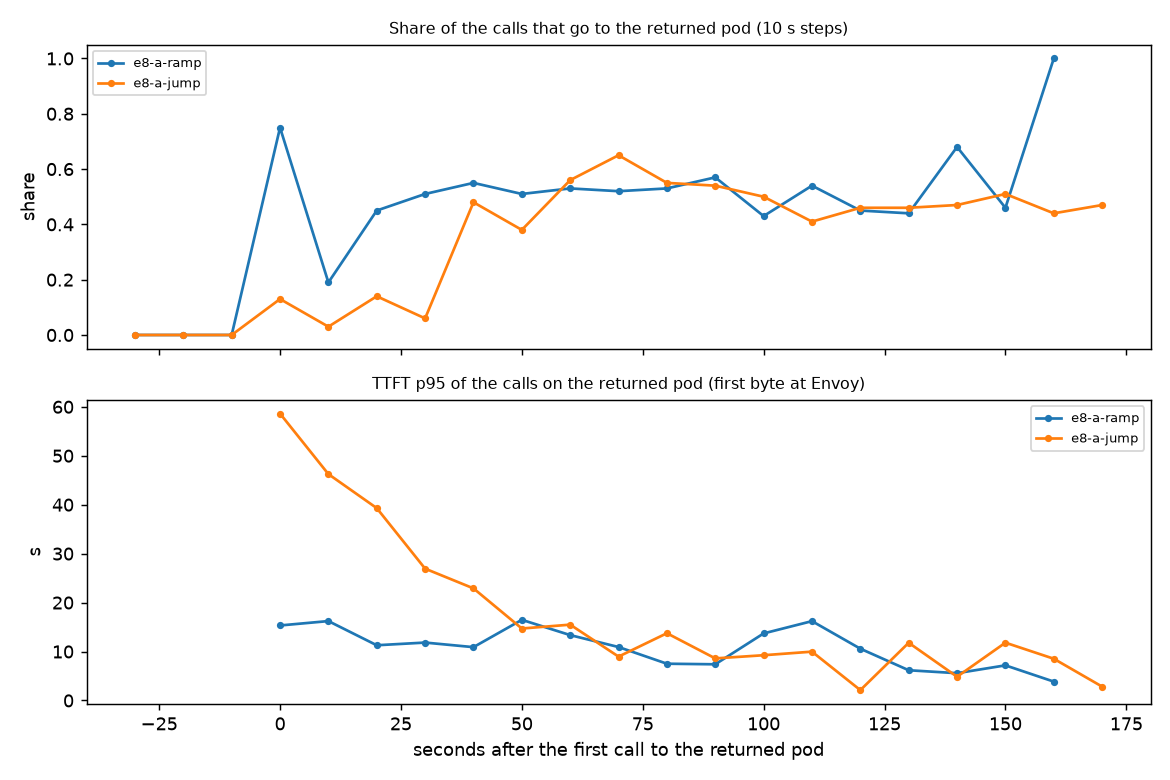

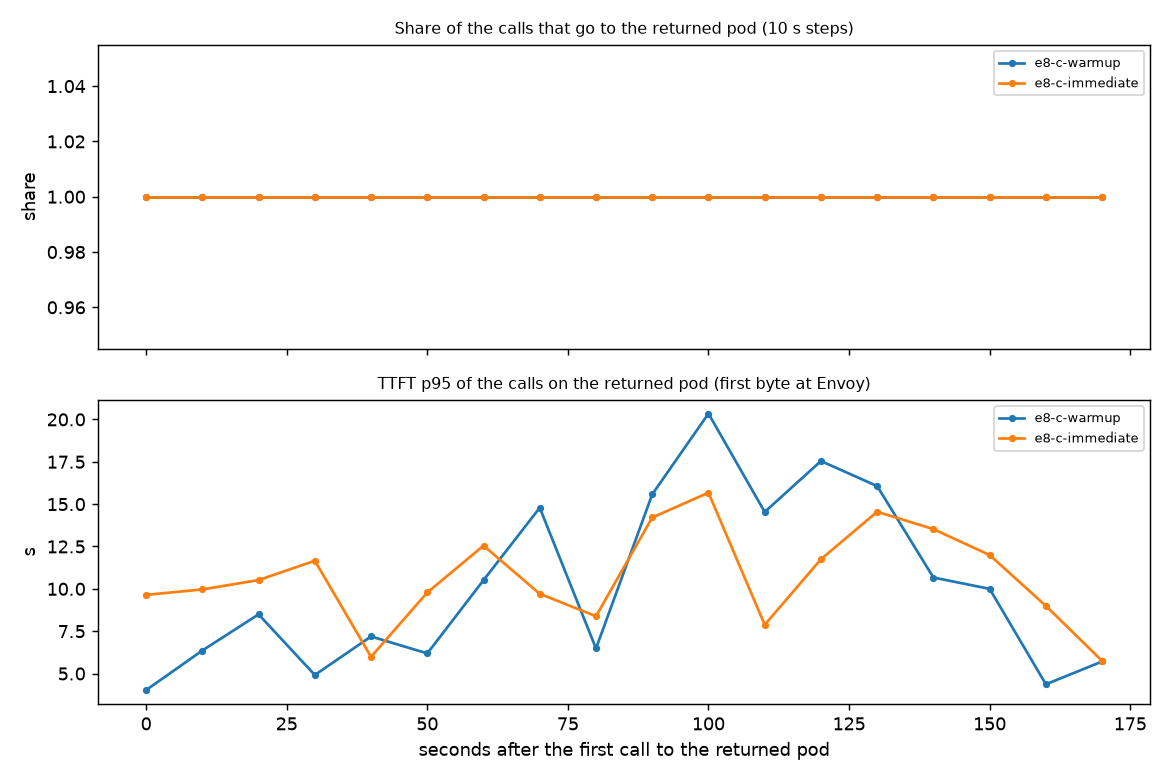

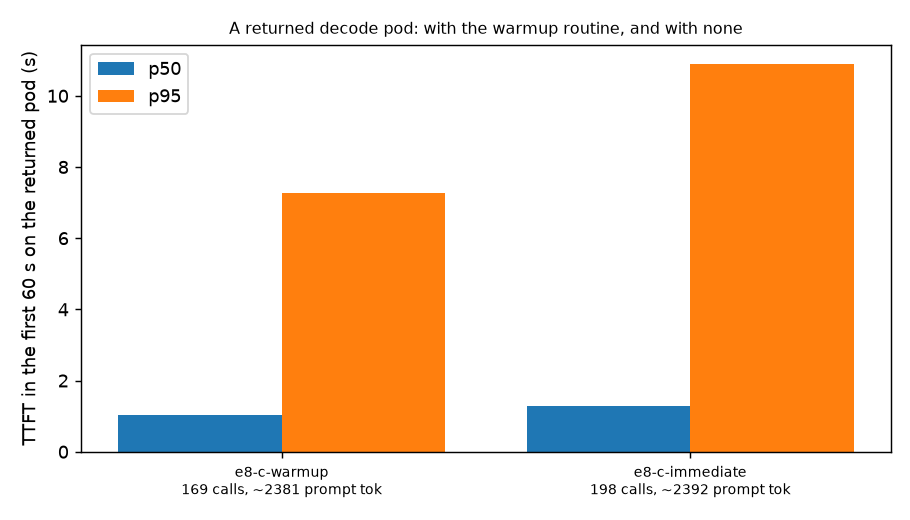

In [12]:
for r in ("e8-a-ramp", "e8-a-jump", "e8-c-warmup", "e8-c-immediate"):
    print(proof.new_pod_window(proof.load_run(r)))
show(proof.new_pod_plot([proof.load_run(r) for r in ("e8-a-ramp", "e8-a-jump")], name="e8-a-new-pod.png"))
show(proof.new_pod_plot([proof.load_run(r) for r in ("e8-c-warmup", "e8-c-immediate")],
                        name="e8-c-new-pod.png"))
show(proof.warmup_first_minute([proof.load_run(r) for r in ("e8-c-warmup", "e8-c-immediate")]))

## E9: which pool scales (2026-10-01, one node)

At each time, only one pool was free to grow, and KEDA permitted 2 pods for each pool. Decode-heavy load: the planner asked for a second decode pod, and KEDA made it 15 s later. Prefill-heavy load: the planner asked for a second prefill pod only after we set its capacity to the A100 value (the dotted line). Each new pod got the warm label about 4 minutes after the request.

e9-decode {'pool': 'decode', 'asked': 1790914380.0, 'made': 1790914395.0, 'pod': 'vllm-decode-d97df4456-cfgrw', 'engine_up': 1790914595.0, 'warm': 1790914615.0, 'made_after_s': 15.0, 'engine_up_after_s': 215.0, 'warm_after_s': 235.0, 'planner_max': 4.0, 'replicas_max': 2.0, 'new_pod_running_max': 24.0, 'new_pod_ramp_weight_max': 0.1}
e9-prefill {'pool': 'prefill', 'asked': 1790916232.0, 'made': 1790916247.0, 'pod': 'vllm-prefill-7c9b584f86-xhrjf', 'engine_up': 1790916442.0, 'warm': 1790916457.0, 'made_after_s': 15.0, 'engine_up_after_s': 210.0, 'warm_after_s': 225.0, 'planner_max': 4.0, 'replicas_max': 2.0, 'new_pod_running_max': 1.0, 'new_pod_ramp_weight_max': 0.1}


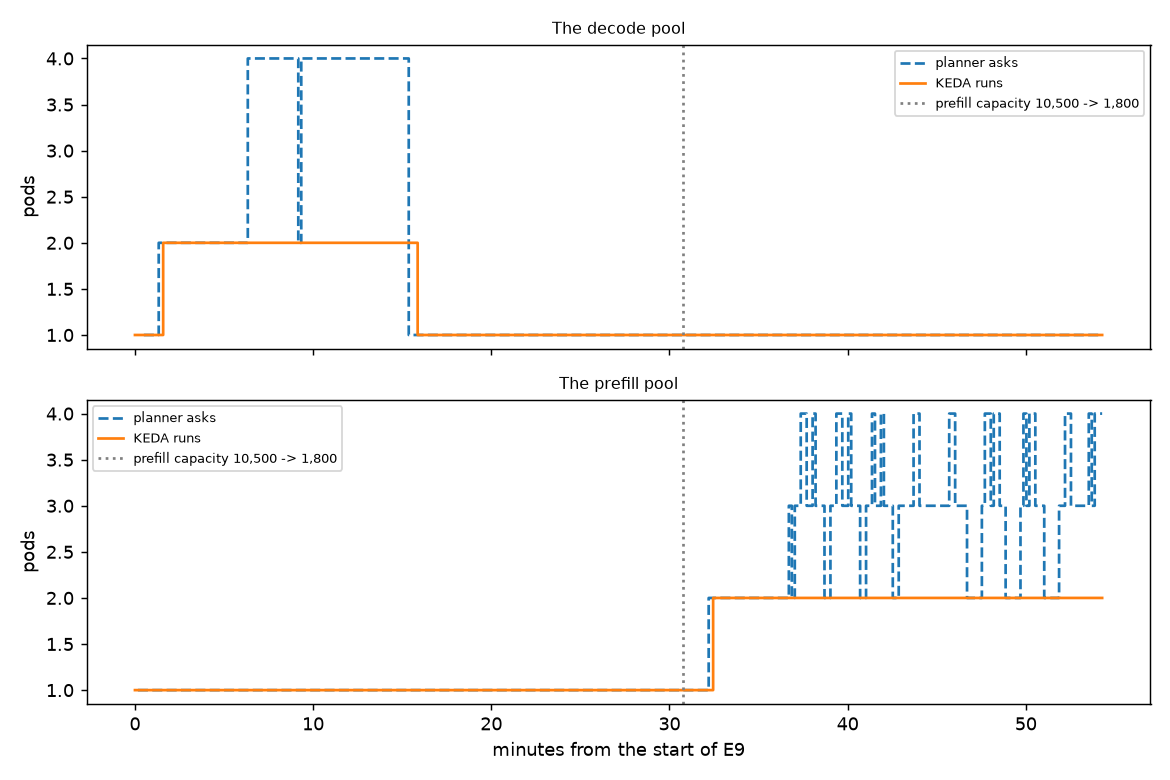

In [13]:
for rid, pool in (("e9-decode", "decode"), ("e9-prefill", "prefill")):
    print(rid, proof.scale_events(proof.load_run(rid), pool))
show(proof.e9_scale_plot(["e9-decode", "e9-prefill"],
                         marks={"prefill capacity 10,500 -> 1,800": 1790916147}))

## E10: tenant isolation, FCFS against EDF

The noisy tenant got 429 `tenant_tokens`. In the interactive band, FCFS gave a lower TTFT than EDF.

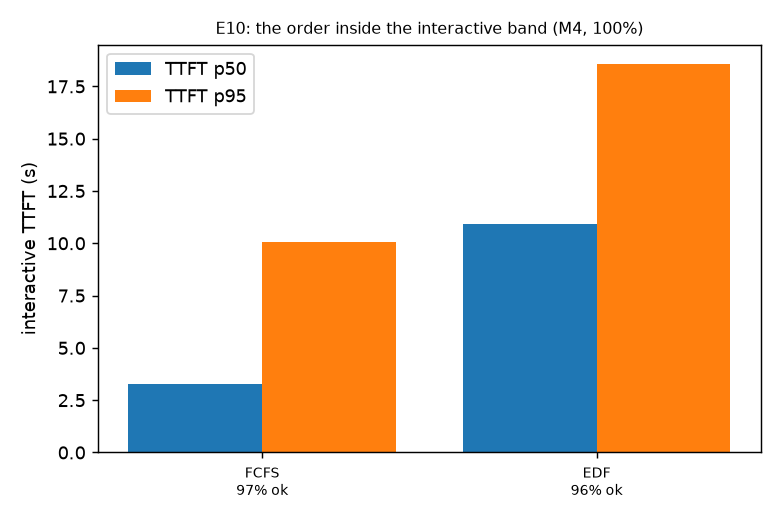

In [14]:
show(proof.ttft_bars([("FCFS", "e10-fcfs"), ("EDF", "e10-edf")], "e10-order.png",
                     "E10: the order inside the interactive band (M4, 100%)"))

## E11: stale metrics

Pod B serves real metrics, a frozen snapshot of an empty pod, or no answer. With the frozen snapshot, the router sent 80% of the work to pod B. With no answer, it sent 8%. With real metrics, it sent 51%.

pass {'vllm-decode-689ccb8d6b-9xnz7': 0.51, 'vllm-prefill-779cbbc7cd-s2sk9': 0.49}
frozen {'vllm-decode-689ccb8d6b-9xnz7': 0.8, 'vllm-prefill-779cbbc7cd-s2sk9': 0.2}
stall {'vllm-decode-689ccb8d6b-9xnz7': 0.08, 'vllm-prefill-779cbbc7cd-s2sk9': 0.92}


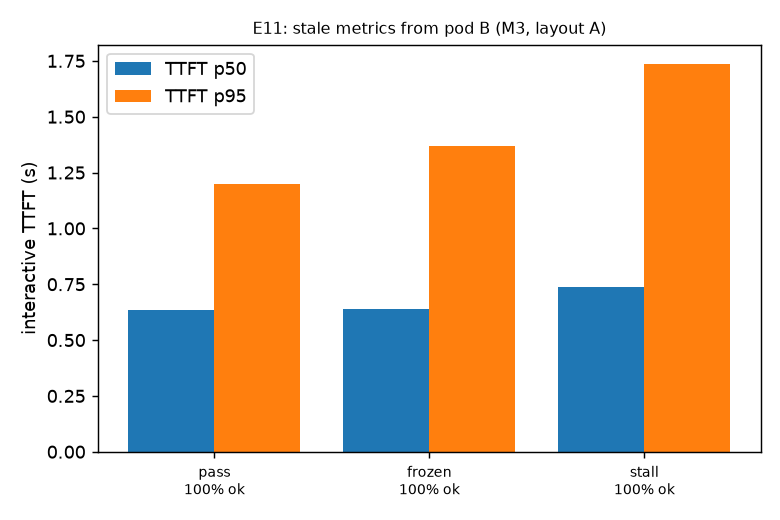

In [15]:
for m in ("pass", "frozen", "stall"):
    print(m, proof.work_share(proof.load_run(f"e11-{m}")))
show(proof.ttft_bars([("pass", "e11-pass"), ("frozen", "e11-frozen"), ("stall", "e11-stall")],
                     "e11-stale.png", "E11: stale metrics from pod B (M3, layout A)"))

## E14: who goes first

A retrieve of about 27,400 tokens and five short agent steps are ready at the same time.

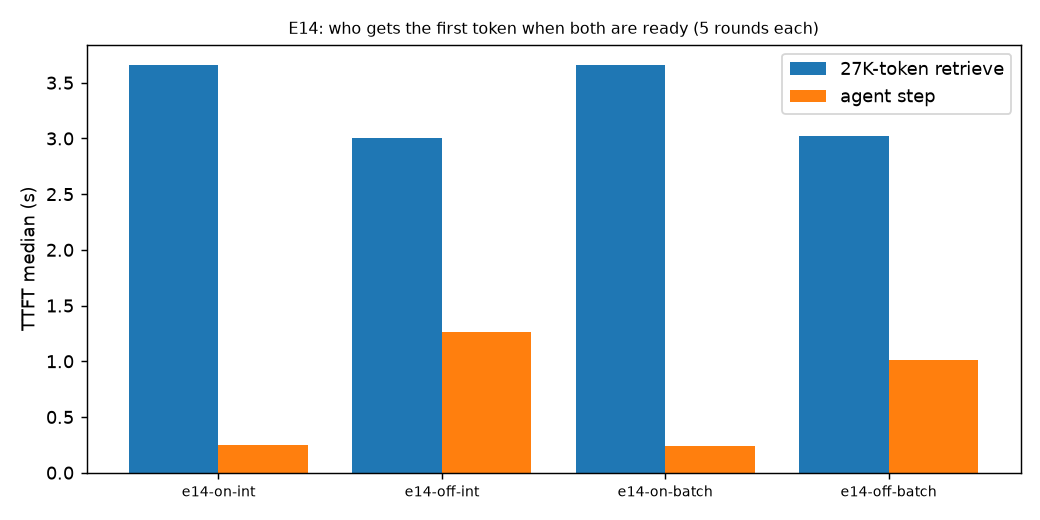

In [16]:
show(proof.queue_order_plot(["e14-on-int", "e14-off-int", "e14-on-batch", "e14-off-batch"]))

## E15: engine flags

One change at a time, against the base of E3 at 100% load. 32 decode sequences gave the best TTFT.

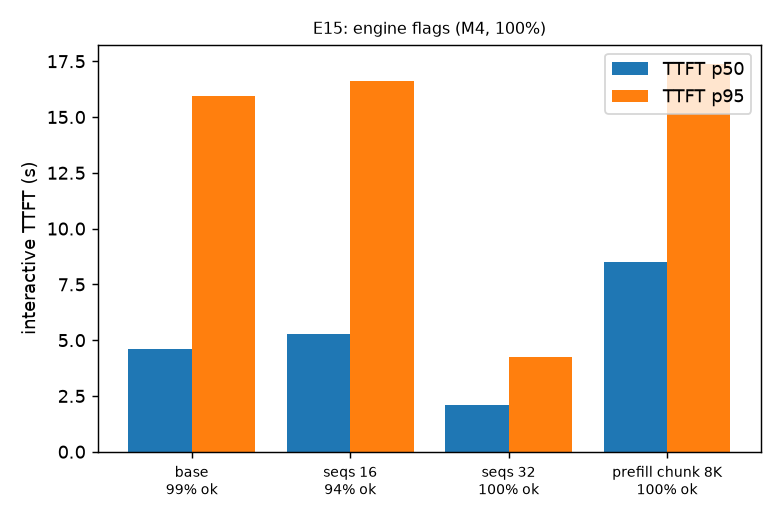

In [17]:
show(proof.ttft_bars([("base", "e3-c-100"), ("seqs 16", "e15-seqs-16"), ("seqs 32", "e15-seqs-32"),
                      ("prefill chunk 8K", "e15-mnbt-8k")], "e15-flags.png", "E15: engine flags (M4, 100%)"))

## E16: the CPU tier after a restart

With the LMCache tier (K2), the restarted decode pod loaded its prefixes from the tier. With no tier (K0), the TTFT p50 after the restart was about five times higher.

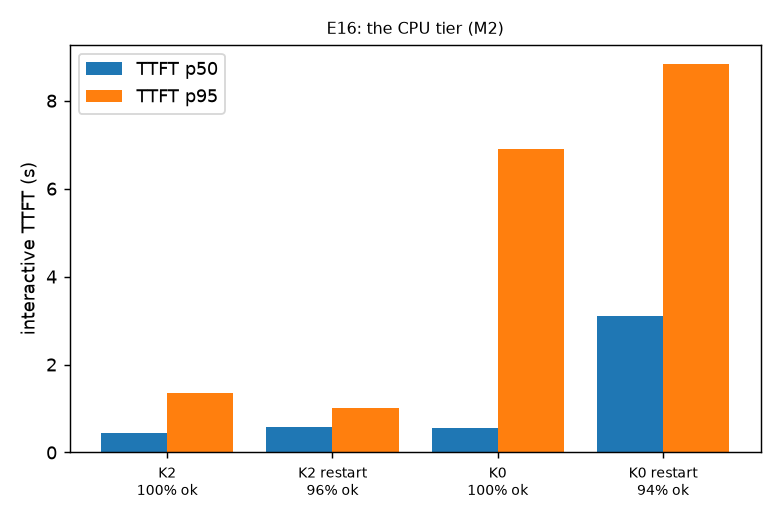

In [18]:
show(proof.ttft_bars([("K2", "e16-k2"), ("K2 restart", "e16-k2-restart"), ("K0", "e16-k0"),
                      ("K0 restart", "e16-k0-restart")], "e16-tier.png", "E16: the CPU tier (M2)"))

## E17: the guard

The chat guard blocked all attack turns and no benign turn. The page check missed half of the injected pages.

In [19]:
for f in ("latency.json", "pages.json"):
    d = json.loads((ROOT / "metrics" / "e17" / f).read_text())
    print(f, {k: v for k, v in d.items() if k not in ("real_scores", "injected_scores")})

latency.json {'turns': 200, 'cold': {'p50_s': 0.1918, 'p95_s': 0.2792}, 'warm': {'p50_s': 0.0008, 'p95_s': 0.0011}, 'attacks_blocked': 22, 'attacks': 22, 'benign_blocked': 0, 'benign': 178}
pages.json {'pages': 50, 'seconds': 4.21, 'rates': [{'threshold': 0.3, 'false_positive_rate': 0.0, 'miss_rate': 0.5}, {'threshold': 0.5, 'false_positive_rate': 0.0, 'miss_rate': 0.52}, {'threshold': 0.7, 'false_positive_rate': 0.0, 'miss_rate': 0.52}, {'threshold': 0.9, 'false_positive_rate': 0.0, 'miss_rate': 0.54}]}


## The demo check on 8 x A100 80 GB (2026-10-01)

The acceptance run (`app/demo_check.py`) after the demo fixes. Three reports are debug runs of D-07 during the E3 load. `docs/results.md` has a note for each report. D-08 passed after the fix. D-07 now gives an answer, but its claims have no evidence: the docs page gave 404.

In [20]:
for f in sorted((ROOT / "metrics" / "demo").glob("demo-check-20261002T*.json")):
    d = json.loads(f.read_text())
    items = d if isinstance(d, list) else d.get("results", [])
    print(f.stem, " ".join(f'{it["id"]} {"pass" if it["pass"] else "fail"}' for it in items))

demo-check-20261002T020050Z D-01 pass D-02 fail D-03 fail D-04 pass D-05 pass D-06 pass D-07 fail D-08 fail D-09 fail D-10 fail D-11 pass D-12 pass
demo-check-20261002T020134Z D-07 fail D-08 pass
demo-check-20261002T022021Z D-07 fail
demo-check-20261002T022451Z D-07 fail
demo-check-20261002T023006Z D-07 fail
demo-check-20261002T050815Z D-03 fail D-07 fail D-08 pass D-09 fail
